In [51]:
from kafka import KafkaConsumer
import pandas as pd
import json
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from IPython.display import display, SVG, Image
load_dotenv()

True

In [52]:
KAFKA_PORT=os.getenv("KAFKA_PORT", 9092)
topic = "user-interactions"
consumer = KafkaConsumer(
    topic, 
    enable_auto_commit=True,
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
    auto_offset_reset='earliest', 
    bootstrap_servers=['localhost:9092'])
messages=consumer.poll(timeout_ms=1000,max_records=10000)
df = []
for m in messages.values():
    for i in m:
        df.append(i.value)
df = pd.DataFrame(df)
# explode metadata col json
df = df.join(pd.json_normalize(df.pop("metadata"), sep=".").add_prefix("metadata_"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sessionId             73 non-null     object 
 1   eventName             73 non-null     object 
 2   page                  73 non-null     object 
 3   productId             67 non-null     object 
 4   storeMode             73 non-null     object 
 5   userAgent             73 non-null     object 
 6   ts                    73 non-null     object 
 7   metadata_referrer     6 non-null      object 
 8   metadata_roomType     45 non-null     object 
 9   metadata_price        45 non-null     float64
 10  metadata_nights       45 non-null     float64
 11  metadata_elementText  22 non-null     object 
 12  metadata_dwellTime    22 non-null     float64
dtypes: float64(3), object(10)
memory usage: 7.5+ KB


In [53]:
df.groupby('sessionId').head()

,sessionId,eventName,page,productId,storeMode,userAgent,ts,metadata_referrer,metadata_roomType,metadata_price,metadata_nights,metadata_elementText,metadata_dwellTime
0,d176d7c9-4027-4702-9e31-2a71395cdda0,page_view,/products,None,hotel,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,2025-11-14T13:23:46.270Z,,NaN,NaN,NaN,NaN,NaN
1,f0317a5d-e424-44e9-b784-c8f7291ffe31,page_view,/,None,hotel,Mozilla/5.0 (X11; Linux x86_64; rv:143.0) Geck...,2025-11-14T13:26:00.291Z,,NaN,NaN,NaN,NaN,NaN
2,f0317a5d-e424-44e9-b784-c8f7291ffe31,page_view,/products,None,hotel,Mozilla/5.0 (X11; Linux x86_64; rv:143.0) Geck...,2025-11-14T13:26:07.769Z,,NaN,NaN,NaN,NaN,NaN
3,f0317a5d-e424-44e9-b784-c8f7291ffe31,view_item_page,/products,htl-0,hotel,Mozilla/5.0 (X11; Linux x86_64; rv:143.0) Geck...,2025-11-14T13:26:15.010Z,NaN,Premium Room,269.0,1.0,NaN,NaN
4,238dc588-a7ab-4c0e-bccd-6abca5076c66,page_view,/products,None,hotel,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2025-11-14T13:27:15.457Z,,NaN,NaN,NaN,NaN,NaN
5,238dc588-a7ab-4c0e-bccd-6abca5076c66,view_item_page,/products,htl-0,hotel,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2025-11-14T13:27:15.591Z,NaN,Premium Room,264.0,2.0,NaN,NaN
6,238dc588-a7ab-4c0e-bccd-6abca5076c66,view_item_page,/products,htl-0,hotel,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2025-11-14T13:27:21.483Z,NaN,Premium Room,264.0,2.0,NaN,NaN
7,238dc588-a7ab-4c0e-bccd-6abca5076c66,hover_over_title,/products,htl-0,hotel,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2025-11-14T13:27:22.646Z,NaN,NaN,NaN,NaN,Grand Plaza Hotel,1200.0
8,238dc588-a7ab-4c0e-bccd-6abca5076c66,view_item_page,/products,htl-0,hotel,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2025-11-14T13:27:25.889Z,NaN,Premium Room,264.0,2.0,NaN,NaN
35,013fc334-4045-4d5a-8739-dd0a8766a63b,page_view,/products,None,hotel,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,2025-11-14T13:53:59.993Z,,NaN,NaN,NaN,NaN,NaN


In [54]:
sessions = list(set(df['sessionId'])); sessions # 238dc588-a7ab-4c0e-bccd-6abca5076c66

['238dc588-a7ab-4c0e-bccd-6abca5076c66',
 'f0317a5d-e424-44e9-b784-c8f7291ffe31',
 'd176d7c9-4027-4702-9e31-2a71395cdda0',
 '013fc334-4045-4d5a-8739-dd0a8766a63b']

In [55]:
# map sessions to experiments

In [56]:
def build_transition_prob_matrix(df: pd.DataFrame):
    df = df.dropna(subset=['eventName'])
    events = df['eventName'].tolist()
    labels = pd.Index(events).unique().tolist()
    idx = {e:i for i,e in enumerate(labels)}
    M = np.zeros((len(labels), len(labels)), dtype=float)
    for a, b in zip(events, events[1:]):
        M[idx[a], idx[b]] += 1
    row_sums = M.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        P = np.divide(M, row_sums, where=row_sums>0)  # row-normalized
    return P, labels

In [57]:
# https://medium.com/data-science/time-series-data-markov-transition-matrices-7060771e362b
from graphviz import Digraph
import numpy as np
import pandas as pd

def _as_prob_df(matrix, labels=None):
    """Return a square DataFrame with index=columns=labels."""
    if isinstance(matrix, pd.DataFrame):
        # Ensure square and aligned
        assert (matrix.index == matrix.columns).all(), "Index/columns must match."
        return matrix
    matrix = np.asarray(matrix, dtype=float)
    assert matrix.shape[0] == matrix.shape[1], "Matrix must be square."
    if labels is None:
        raise ValueError("labels are required when matrix is not a DataFrame")
    assert len(labels) == matrix.shape[0], "labels length must match matrix size."
    return pd.DataFrame(matrix, index=list(labels), columns=list(labels))

def _df_to_edgelist(P: pd.DataFrame, threshold=0.0, round_digits=2):
    """Build weighted edges > threshold."""
    edges = []
    for src in P.index:
        for dst in P.columns:
            w = float(P.loc[src, dst])
            if w > threshold:
                edges.append((str(src), str(dst), f"{w:.{round_digits}f}"))
    return edges

def render_graph(fname, matrix, ls_index=None, threshold=0.0, fmt="svg", view=False):
    """
    fname: output file stem (no extension)
    matrix: NumPy array or pandas DataFrame of transition PROBABILITIES
    ls_index: ordered labels (required if matrix is not a DataFrame)
    threshold: hide edges with weight <= threshold
    fmt: 'svg'|'png'|'pdf' etc.
    view: open after rendering
    """
    P = _as_prob_df(matrix, labels=ls_index)
    edges = _df_to_edgelist(P, threshold=threshold)

    g = Digraph(format=fmt)
    g.attr(rankdir="LR", size="30")
    g.attr("node", shape="circle")

    # ensure isolated nodes appear
    for node in P.index:
        g.node(str(node), width="1", height="1")

    for src, dst, label in edges:
        g.edge(src, dst, label=label)

    g.render(fname, view=view, cleanup=True)
    return g


238dc588-a7ab-4c0e-bccd-6abca5076c66


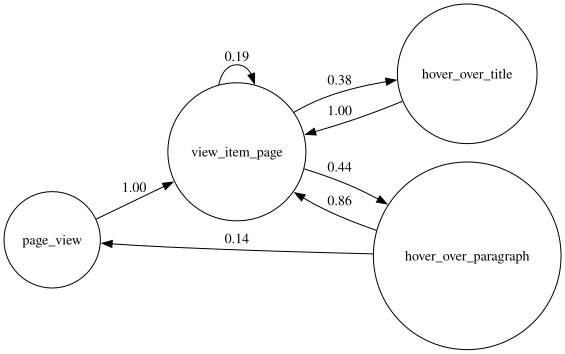

[[0.         1.         0.         0.        ]
 [0.         0.1875     0.375      0.4375    ]
 [0.         1.         0.         0.        ]
 [0.14285714 0.85714286 0.         0.        ]]
f0317a5d-e424-44e9-b784-c8f7291ffe31


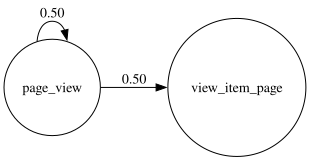

[[5.0e-001 5.0e-001]
 [9.9e-324 1.5e-323]]
d176d7c9-4027-4702-9e31-2a71395cdda0


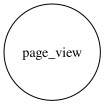

[[0.]]
013fc334-4045-4d5a-8739-dd0a8766a63b


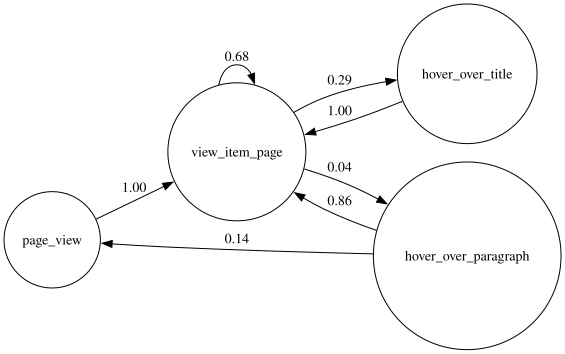

[[0.         1.         0.         0.        ]
 [0.         0.67857143 0.28571429 0.03571429]
 [0.         1.         0.         0.        ]
 [0.14285714 0.85714286 0.         0.        ]]


In [58]:
def explore_session(session_id: str):
    subset = df[df['sessionId'] == session_id]
    print(session_id)
    P, labels = build_transition_prob_matrix(subset)
    g = render_graph(f"session_{session_id}", P, ls_index=labels, threshold=0.01, fmt="svg", view=False)
    display(g)
    return P
for session in sessions:
    print(explore_session(session))